# White Noise Drive Qubit Excitation Spectrum

### Author: Daniel Gonçalves Benvenutti - UNICAMP
15 August 2025

Qutip Version: 5.2.0









In [3]:
# to use in google colab
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 62.1 MB/s eta 0:00:00


In [1]:
import qutip as qtp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm import tqdm
#from tqdm.notebook import tqdm

## Simulation Parameters



In [7]:
# parameters
wq=3*2*np.pi #qubit resonance frequency [GHz.rad]

# operators
sm=qtp.destroy(2)
sx=qtp.sigmax()
sz=qtp.sigmaz()
sy=qtp.sigmay()
n=sm.dag()*sm

# hamiltonian
def H(wq, Ed_t, tlist):# wq[rad.GHz], Ed_t[rad.GHz], tlist[ns]
  # time independant hamiltonian (normalized by wq)
  if Ed_t is None:
    return -0.5*wq*sz/wq
  # time dependant hamiltonian
  # [time independant part, [operator,time dependant operator amplitude]]
  # [qubit, [drive]]
  return qtp.QobjEvo([-0.5*wq*sz/wq,[sx/wq,Ed_t]],tlist=tlist*wq)

# colapse operators normalized by wq
def c_ops(T1, T2): #T1[ns], T2[ns]
  if T2 is None:
    return [np.sqrt(1/T1/wq)*sm]
      # (T2 must be T2<=2T1)
  elif T2>2*T1:
    raise Exception("T2 must be T2<=2T1")
  gamma_phi=1/T2-1/2/T1 #pure dephasing constant
  return [np.sqrt(1/T1/wq)*sm,np.sqrt(gamma_phi/2/wq)*sz]
  #return [np.sqrt(1/T1)*sm,np.sqrt(2*gamma_phi)*n] #same thing for dephasing but in different terms

def simulation(Ed,T1, T2, e="xyz"):
  lenght=2000 #ns
  #pi_pulse=np.pi/Ed #[ns]
  #print(f"pi pulse={pi_pulse:.2e}ns")
  # expected value operators desired (present in sting "e")
  e_ops=[]
  if "x" in e:
    e_ops.append(sx)
  if "y" in e:
    e_ops.append(sy)
  if "z" in e:
    e_ops.append(sz)

  #White noise generator
  tlist=np.linspace(0,lenght,int(lenght*300*wq/2/np.pi))
  drive_data=Ed*np.random.normal(0,1, tlist.shape) #10% Ed amplitude

  #simulation steps
  t=np.linspace(0,lenght,int(lenght*12*wq/2/np.pi)) #ns

  # initial state
  psi0=qtp.basis(2,0)
  options=dict(nsteps=5000, atol=5e-9, rtol=5e-7)
  res=qtp.mesolve(H(wq,drive_data,tlist),psi0,t*wq,c_ops=c_ops(T1,T2),e_ops=e_ops,options=options)
  return t, res


# Plots

In [3]:
def plot_fft_tomography(t, expect, graphs="xyz"):
   # string graphs selects plots to make with presence of letters
  fig, axes = plt.subplots(len(graphs), 1, figsize=(8, int(3*len(graphs))))  # Adjust figure size as needed
  axes = np.atleast_1d(axes)

  # Calculate the corresponding frequencies
  freq = np.fft.rfftfreq(len(t), d=t[1] - t[0])

  # Plot sx
  if "x" in graphs:
    axes[graphs.index("x")].plot(freq, np.abs(np.fft.rfft(expect[graphs.index("x")])))
    axes[graphs.index("x")].set_xlabel('Frequency (GHz)')
    axes[graphs.index("x")].set_ylabel('<σx>')
    axes[graphs.index("x")].set_title(r'Tomography of the noisy oscillation \n Expectation Value of $\sigma_x$')


  # Plot sy
  if "y" in graphs:
    axes[graphs.index("y")].plot(freq, np.abs(np.fft.rfft(expect[graphs.index("y")])))
    axes[graphs.index("y")].set_xlabel('Frequency (GHz)')
    axes[graphs.index("y")].set_ylabel('<σy>')
    axes[graphs.index("y")].set_title(r'Expectation Value of $\sigma_y$')

  # Plot sz
  if "z" in graphs:
    axes[graphs.index("z")].plot(freq[1:], np.abs(np.fft.rfft(expect[graphs.index("z")])[1:]))
    axes[graphs.index("z")].set_xlabel('Frequency (GHz)')
    axes[graphs.index("z")].set_ylabel('<σz>')
    axes[graphs.index("z")].set_title(r'Expectation Value of $\sigma_z$')
    print(f"DC: {np.fft.rfft(expect[graphs.index("z")])[0]}")


  plt.tight_layout()  # Adjust spacing between subplots
  plt.show()

def plot_tomography(t, expect, graphs="xyz"):
   # string graphs selects plots to make with presence of letters
  fig, axes = plt.subplots(len(graphs), 1, figsize=(8, int(3*len(graphs))))   # Adjust figure size as needed
  axes = np.atleast_1d(axes)
  # Plot sx
  if "x" in graphs:
    axes[graphs.index("x")].plot(t, expect[graphs.index("x")])
    axes[graphs.index("x")].set_xlabel('Time (ns)')
    axes[graphs.index("x")].set_ylabel('<σx>')
    axes[graphs.index("x")].set_title(r'Tomography of the noisy oscillation \n Expectation Value of $\sigma_x$')


  # Plot sy
  if "y" in graphs:
    axes[graphs.index("y")].plot(t, expect[graphs.index("y")])
    axes[graphs.index("y")].set_xlabel('Time (ns)')
    axes[graphs.index("y")].set_ylabel('<σy>')
    axes[graphs.index("y")].set_title(r'Expectation Value of $\sigma_y$')

  # Plot sz
  if "z" in graphs:
    axes[graphs.index("z")].plot(t, expect[graphs.index("z")])
    axes[graphs.index("z")].set_xlabel('Time (ns)')
    axes[graphs.index("z")].set_ylabel('<σz>')
    axes[graphs.index("z")].set_title(r'Expectation Value of $\sigma_z$')


  plt.tight_layout()  # Adjust spacing between subplots
  plt.show()

def diffusive_scale(dt, signal):
    """
    Returns the slope of variance vs lag in log-log scale
    For pure Brownian motion, slope ≈ 1
    """
    n = len(signal)
    lags = np.arange(1, n//2)
    variances = [np.var(signal[lag:] - signal[:-lag]) for lag in lags]
    slope, _ = np.polyfit(np.log(dt*lags), np.log(variances), 1)
    #diffusive scale
    D=slope
    return D

def lorenztian_fit(t, sigz, T, split =100):
    # Calculate the corresponding frequencies
  dt=t[1]-t[0]
  freq = np.fft.rfftfreq(len(t), d=dt)

  start=1 # remove DC
  split=100
  # FFT of sigz betweeen start and split
  X=np.abs(np.fft.rfft(sigz))[start:split]
  freq_subset = freq[start:split]

  # Define the zero-centered Lorentzian function
  def lorentzian(f, A, gamma,offset):
    return A / (1 + (f/gamma)**2)+offset

  # Fit the Lorentzian function to the data
  popt, pcov = curve_fit(lorentzian, freq_subset, X,p0=[500,1/T2/np.pi, 10])

  # Get the fitted parameters
  A_fit, gamma_fit, offset_fit = popt

  # Generate the fitted curve
  X_fit = lorentzian(freq_subset, A_fit, gamma_fit, offset_fit)

  # Plot the original data and the fitted curve
  plt.plot(freq_subset, X, label='Original Data')
  plt.plot(freq_subset, X_fit, label='Fit', color='red')
  plt.xlabel('Frequency (GHz)')
  plt.ylabel('<σz>')
  plt.title(r'Expectation Value of $\sigma_z$ with Lorentzian Fit')
  plt.legend()
  plt.show()

  print(f"Fitted gamma: {gamma_fit:.2e}")
  print(f"Fitted gamma*2pi: {gamma_fit*2*np.pi:.2e}")
  print(f"Fitted 1/gamma/2pi: {1/gamma_fit/2/np.pi:.2e}")
  print(f"Fitted Offset: {offset_fit:.2f}")
  print(f"Fitted Amplitude : {A_fit:.2f}")
  print(f"Fit")
  print(f"var of increments (volatility): {np.var([j-i for i, j in zip(sigz[:-1], sigz[1:])])}")


# Average conserves random walk like property

In [ ]:
T1=10000 #relaxation time [ns]
T2=1000 #dephasing time [ns]
Ed=0.128*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
e="z"
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2, e=e)
  avgz += res.expect[e.index("z")]/samples

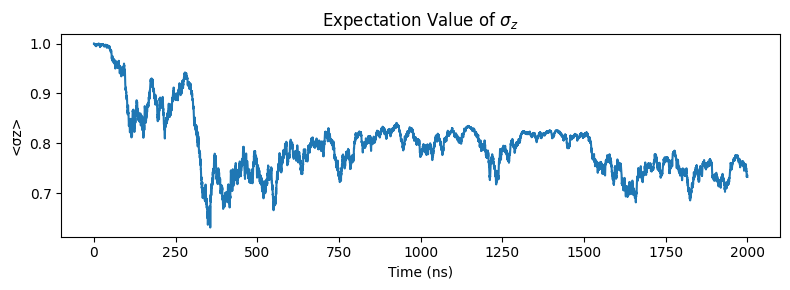

In [26]:
plot_tomography(t, res.expect, graphs="z")

In [27]:
T1=10000 #relaxation time [ns]
T2=1000 #dephasing time [ns]
Ed=0.128*2*np.pi #driving energy [GHz.rad]
samples=10
avgz = 0
e="z"
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2, e=e)
  avgz += res.expect[e.index("z")]/samples

  0%|          | 0/10 [00:00<?, ?it/s]

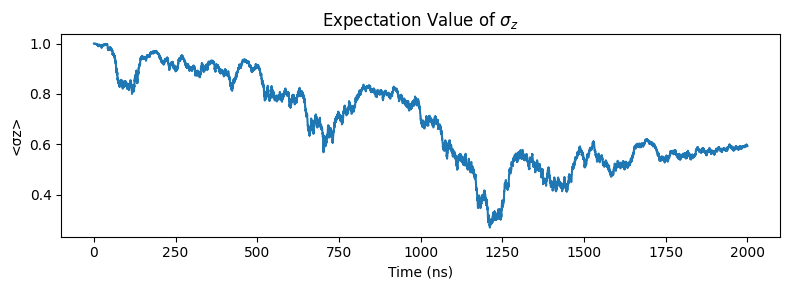

In [28]:
plot_tomography(t, res.expect, graphs="z")

# $T_1=10\mu s , T_2= 200ns$

In [18]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.004*2*np.pi #driving energy [GHz.rad]
samples=5
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 5/5 [06:46<00:00, 81.39s/it] 


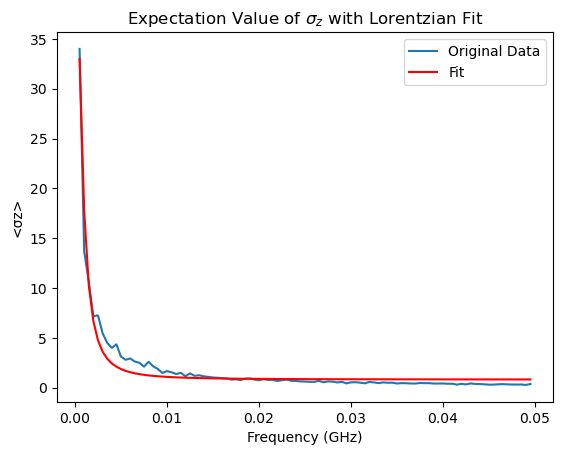

Fitted gamma: 7.65e-04
Fitted gamma*2pi: 4.81e-03
Fitted 1/gamma/2pi: 2.08e+02
Fitted Offset: 0.82
Fitted Amplitude : 45.90
Fit
var of increments (volatility): 2.2371932167487025e-12


In [19]:
lorenztian_fit(t, avgz, T2)

In [20]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.008*2*np.pi #driving energy [GHz.rad]
samples=5
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 5/5 [05:44<00:00, 68.88s/it]


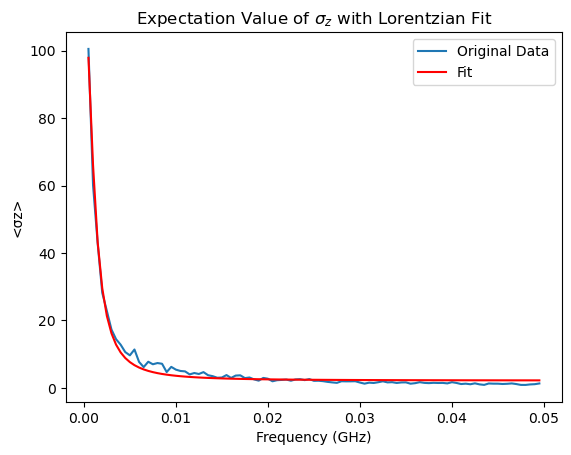

Fitted gamma: 1.12e-03
Fitted gamma*2pi: 7.03e-03
Fitted 1/gamma/2pi: 1.42e+02
Fitted Offset: 2.19
Fitted Amplitude : 114.76
Fit
var of increments (volatility): 2.971181535448607e-11


In [21]:
lorenztian_fit(t, avgz, T2)

In [22]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.016*2*np.pi #driving energy [GHz.rad]
samples=5
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 5/5 [05:35<00:00, 67.18s/it]


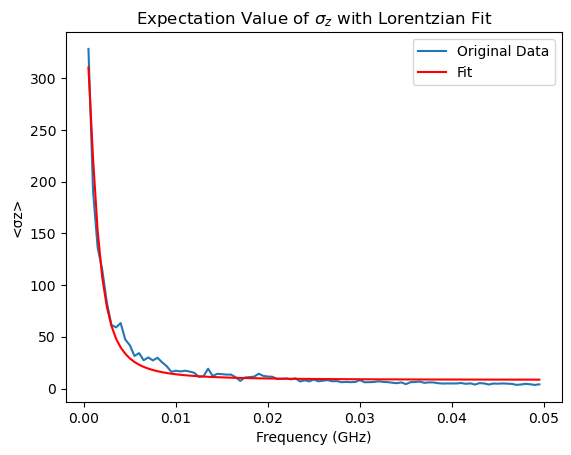

Fitted gamma: 1.26e-03
Fitted gamma*2pi: 7.89e-03
Fitted 1/gamma/2pi: 1.27e+02
Fitted Offset: 8.33
Fitted Amplitude : 350.01
Fit
var of increments (volatility): 4.3768453337908176e-10


In [23]:
lorenztian_fit(t, avgz, T2)

In [24]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.032*2*np.pi #driving energy [GHz.rad]
samples=5
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 5/5 [10:03<00:00, 120.61s/it]


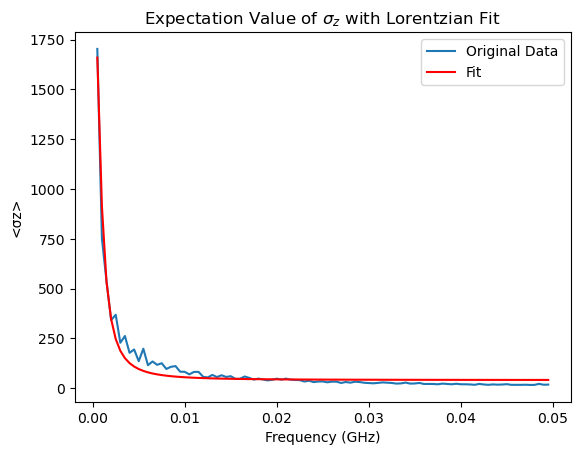

Fitted gamma: -7.90e-04
Fitted gamma*2pi: -4.96e-03
Fitted 1/gamma/2pi: -2.01e+02
Fitted Offset: 40.88
Fitted Amplitude : 2267.95
Fit
var of increments (volatility): 6.920850854051186e-09


In [25]:
lorenztian_fit(t, avgz, T2)

In [26]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.064*2*np.pi #driving energy [GHz.rad]
samples=5
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [09:49<00:00, 117.90s/it]


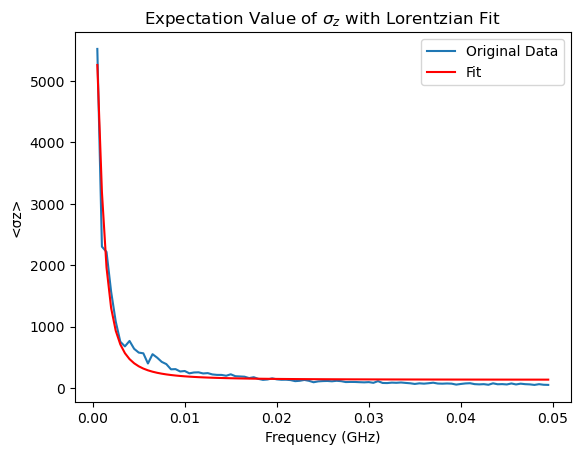

Fitted gamma: 9.26e-04
Fitted gamma*2pi: 5.82e-03
Fitted 1/gamma/2pi: 1.72e+02
Fitted Offset: 136.47
Fitted Amplitude : 6619.03
Fit
var of increments (volatility): 7.753364583708494e-08


In [27]:
lorenztian_fit(t, avgz, T2)

In [28]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.128*2*np.pi #driving energy [GHz.rad]
samples=5
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 5/5 [06:27<00:00, 77.57s/it]


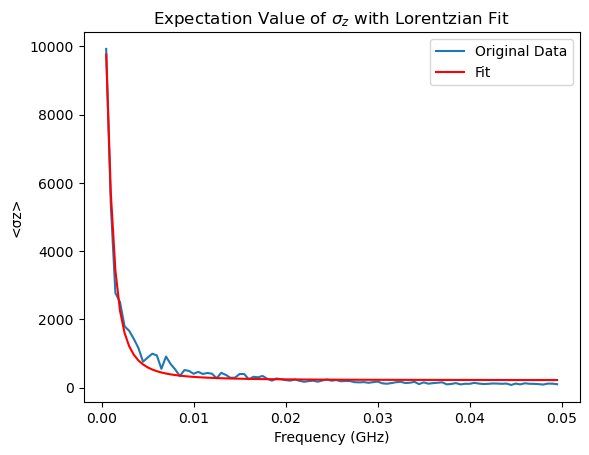

Fitted gamma: 8.75e-04
Fitted gamma*2pi: 5.50e-03
Fitted 1/gamma/2pi: 1.82e+02
Fitted Offset: 219.52
Fitted Amplitude : 12656.82
Fit
var of increments (volatility): 4.08889805958109e-07


In [29]:
lorenztian_fit(t, avgz, T2)

## Start of regime change

In [30]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.256*2*np.pi #driving energy [GHz.rad]
samples=5
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 5/5 [05:29<00:00, 65.99s/it]


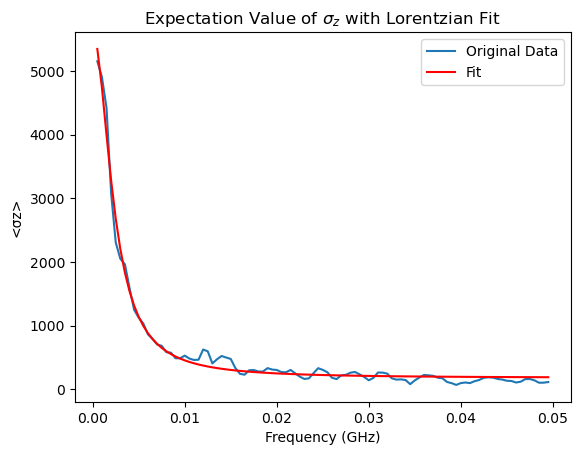

Fitted gamma: 2.32e-03
Fitted gamma*2pi: 1.46e-02
Fitted 1/gamma/2pi: 6.86e+01
Fitted Offset: 176.92
Fitted Amplitude : 5410.10
Fit
var of increments (volatility): 1.6036383167592954e-06


In [31]:
lorenztian_fit(t, avgz, T2)

In [32]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.512*2*np.pi #driving energy [GHz.rad]
samples=5
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 5/5 [07:48<00:00, 93.68s/it] 


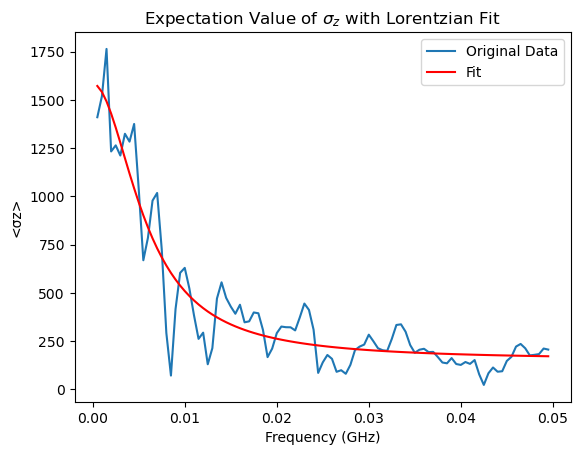

Fitted gamma: -5.77e-03
Fitted gamma*2pi: -3.62e-02
Fitted 1/gamma/2pi: -2.76e+01
Fitted Offset: 152.29
Fitted Amplitude : 1430.03
Fit
var of increments (volatility): 6.289602824163092e-06


In [33]:
lorenztian_fit(t, avgz, T2)

In [34]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.8*2*np.pi #driving energy [GHz.rad]
samples=5
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 5/5 [05:40<00:00, 68.12s/it]


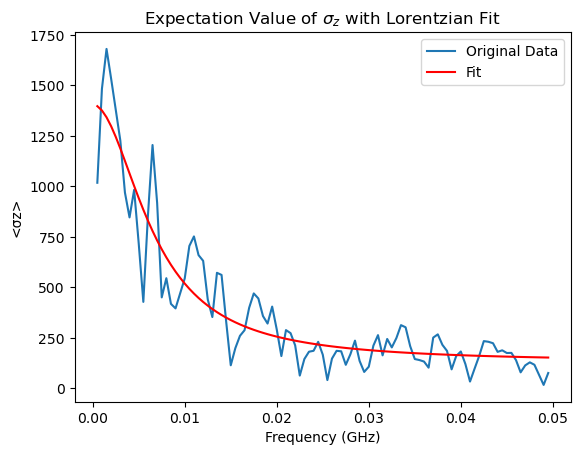

Fitted gamma: -6.63e-03
Fitted gamma*2pi: -4.16e-02
Fitted 1/gamma/2pi: -2.40e+01
Fitted Offset: 129.83
Fitted Amplitude : 1274.44
Fit
var of increments (volatility): 1.5776722806919504e-05


In [35]:
lorenztian_fit(t, avgz, T2)

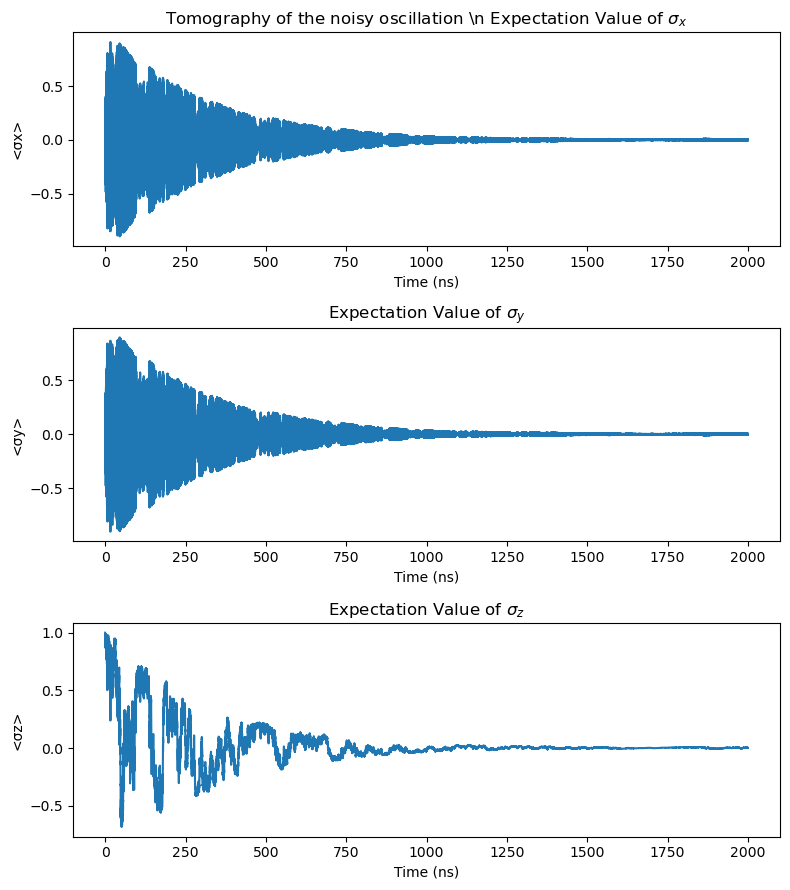

In [39]:
plot_tomography(t, res.expect)

## Final data analysis

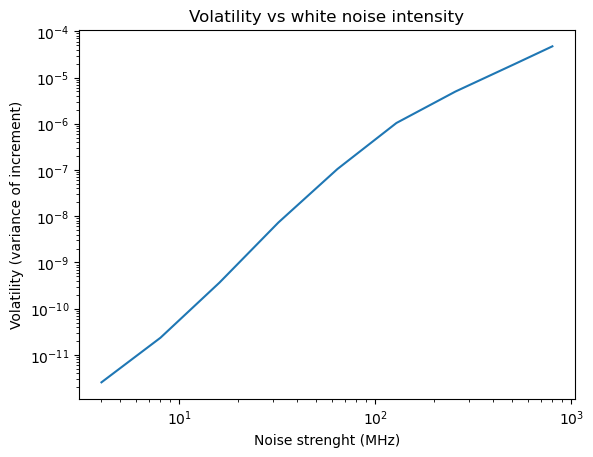

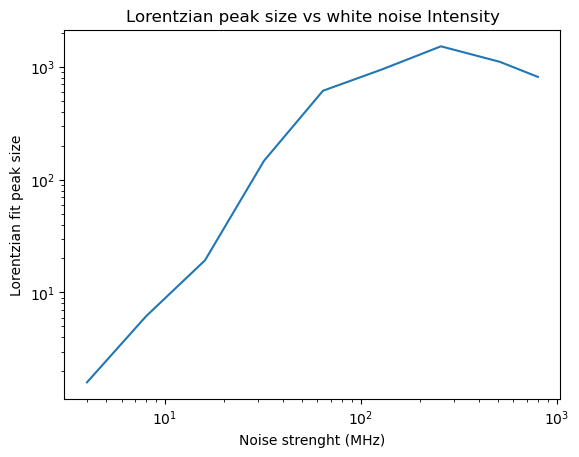

In [9]:
Ed=np.array([0.004,0.008,0.016,0.032,0.064,0.128,0.256,0.512,0.8])
vol=[2.55E-12,2.35E-11,3.66E-10,7.33E-09,1.05E-07,1.04E-06,4.98E-06,1.95E-05,4.74E-05,]
amp=[1.6,6.15,19.27,146.58,612.25,945.99,1515.48,1103.67,811.91,]
plt.loglog(Ed*1000,vol)
plt.xlabel("Noise strenght (MHz)")
plt.ylabel("Volatility (variance of increment)")
plt.title("Volatility vs white noise intensity")

plt.show()
plt.xlabel("Noise strenght (MHz)")
plt.ylabel("Lorentzian fit peak size")
plt.title("Lorentzian peak size vs white noise Intensity")

plt.loglog(Ed*1000,amp)
plt.show()

# Ed=8MHz T2=200ns

In [ ]:
T1=100 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.064*2*np.pi #driving energy [GHz.rad]
samples=5
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 5/5 [07:07<00:00, 85.46s/it] 


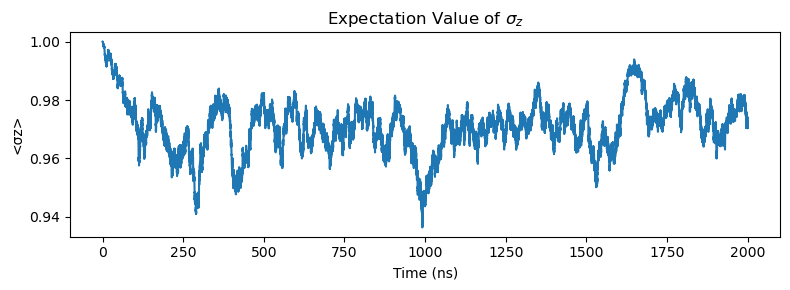

In [57]:
plot_tomography(t, [avgz], graphs="z")

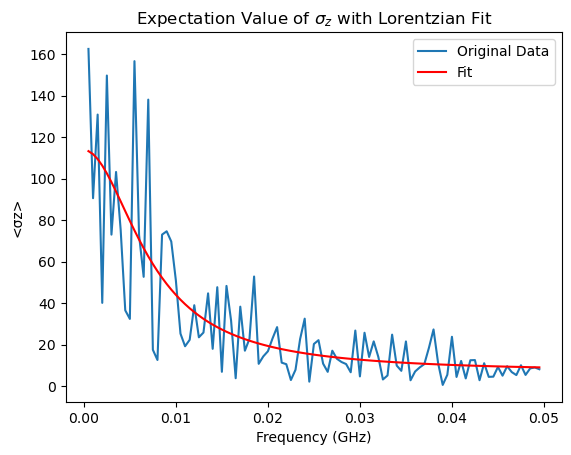

Fitted gamma: 7.30e-03
Fitted gamma*2pi: 4.59e-02
Fitted 1/gamma/2pi: 2.18e+01
Fitted Offset: 6.77
Fitted Amplitude : 107.00
Fit
var of increments (volatility): 1.0939738216241504e-07


In [55]:
lorenztian_fit(t, avgz, T2)

In [74]:
T1=200 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.064*2*np.pi #driving energy [GHz.rad]
samples=5
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 5/5 [07:20<00:00, 88.10s/it] 


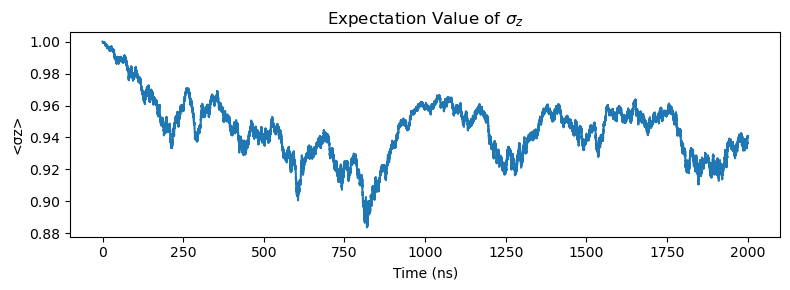

In [75]:
plot_tomography(t, [avgz], graphs="z")

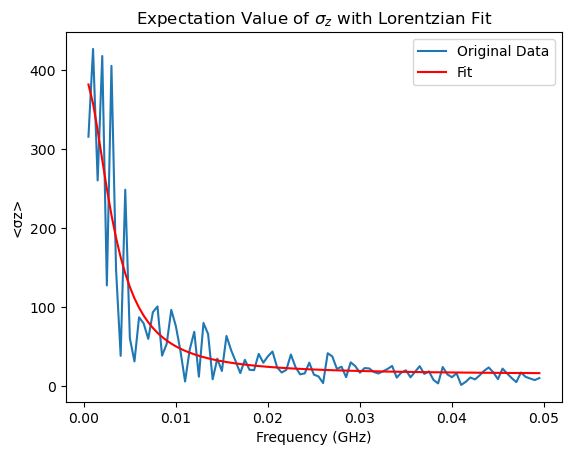

Fitted gamma: 3.23e-03
Fitted gamma*2pi: 2.03e-02
Fitted 1/gamma/2pi: 4.93e+01
Fitted Offset: 14.49
Fitted Amplitude : 375.91
Fit
var of increments (volatility): 1.0784777954912969e-07


In [76]:
lorenztian_fit(t, avgz, T2)

In [77]:
T1=500 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.064*2*np.pi #driving energy [GHz.rad]
samples=5
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 5/5 [06:05<00:00, 73.15s/it]


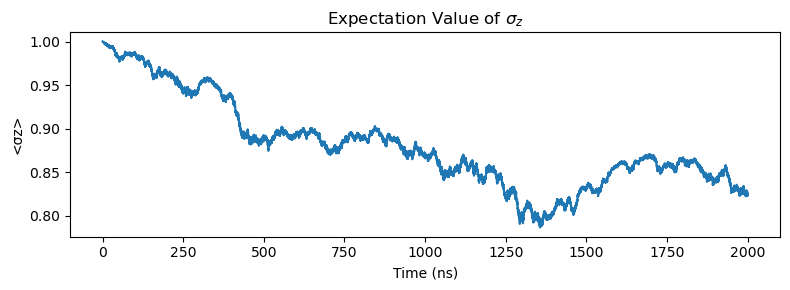

In [78]:
plot_tomography(t, [avgz], graphs="z")

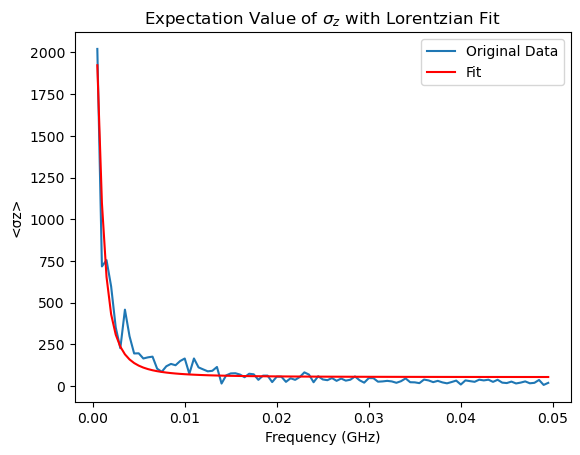

Fitted gamma: 8.35e-04
Fitted gamma*2pi: 5.24e-03
Fitted 1/gamma/2pi: 1.91e+02
Fitted Offset: 53.71
Fitted Amplitude : 2540.26
Fit
var of increments (volatility): 1.0163557562795732e-07


In [79]:
lorenztian_fit(t, avgz, T2)

In [58]:
T1=1000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.064*2*np.pi #driving energy [GHz.rad]
samples=5
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 5/5 [06:45<00:00, 81.17s/it] 


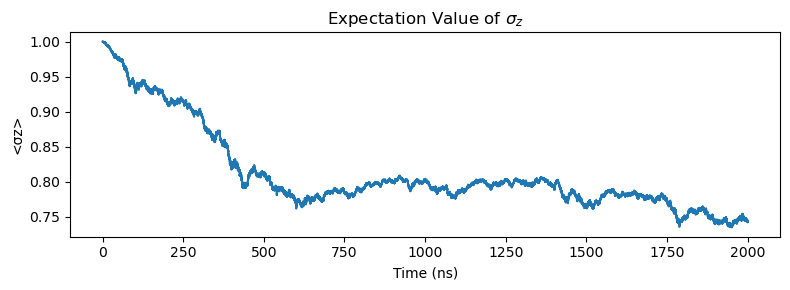

In [59]:
plot_tomography(t, [avgz], graphs="z")

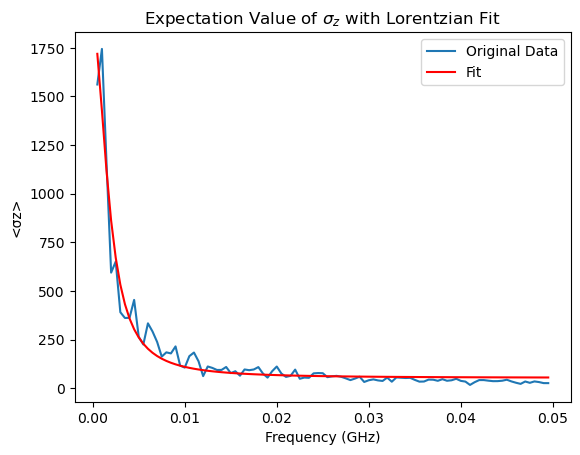

Fitted gamma: 1.81e-03
Fitted gamma*2pi: 1.14e-02
Fitted 1/gamma/2pi: 8.78e+01
Fitted Offset: 53.34
Fitted Amplitude : 1792.54
Fit
var of increments (volatility): 9.542196810882385e-08


In [60]:
lorenztian_fit(t, avgz, T2)

In [61]:
T1=2000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.064*2*np.pi #driving energy [GHz.rad]
samples=5
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 5/5 [05:45<00:00, 69.17s/it]


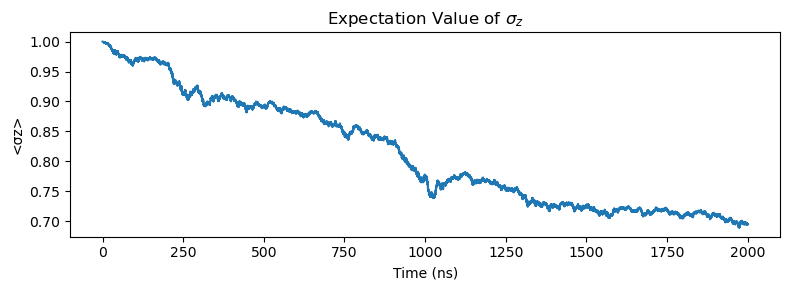

In [62]:
plot_tomography(t, [avgz], graphs="z")

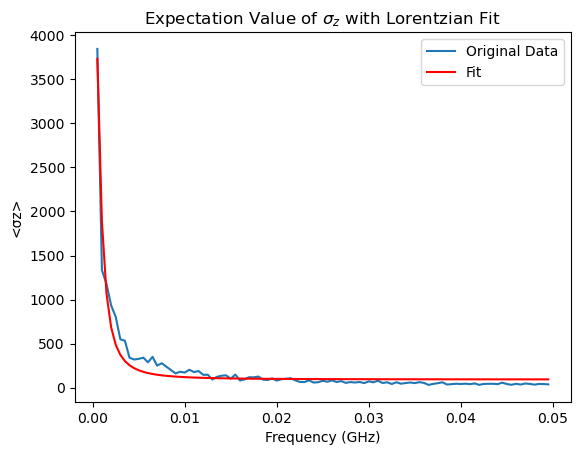

Fitted gamma: 6.92e-04
Fitted gamma*2pi: 4.35e-03
Fitted 1/gamma/2pi: 2.30e+02
Fitted Offset: 92.10
Fitted Amplitude : 5542.26
Fit
var of increments (volatility): 7.588200271257478e-08


In [63]:
lorenztian_fit(t, avgz, T2)

In [64]:
T1=3000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.064*2*np.pi #driving energy [GHz.rad]
samples=5
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 5/5 [05:40<00:00, 68.14s/it]


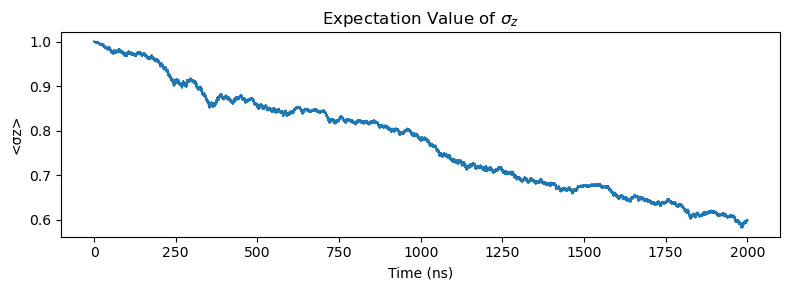

In [65]:
plot_tomography(t, [avgz], graphs="z")

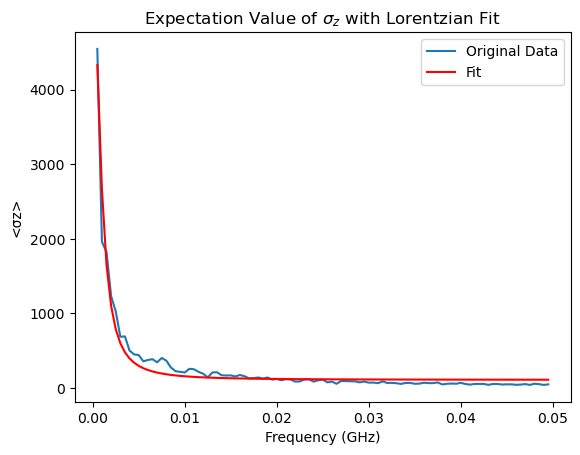

Fitted gamma: -9.50e-04
Fitted gamma*2pi: -5.97e-03
Fitted 1/gamma/2pi: -1.68e+02
Fitted Offset: 109.44
Fitted Amplitude : 5388.56
Fit
var of increments (volatility): 8.103357443392424e-08


In [66]:
lorenztian_fit(t, avgz, T2)

In [67]:
T1=5000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.064*2*np.pi #driving energy [GHz.rad]
samples=5
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 5/5 [05:35<00:00, 67.17s/it]


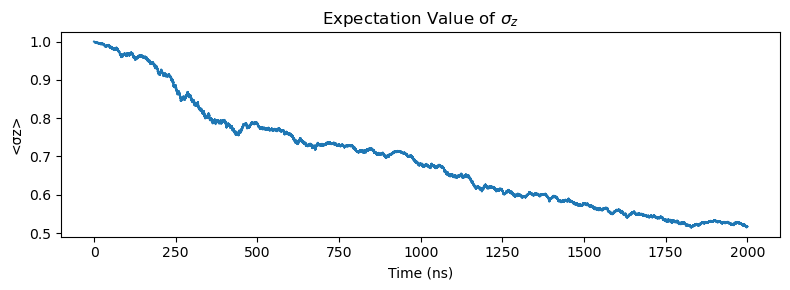

In [68]:
plot_tomography(t, [avgz], graphs="z")

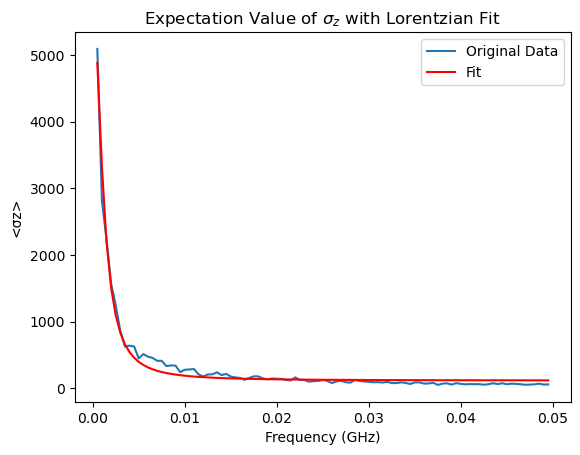

Fitted gamma: -1.14e-03
Fitted gamma*2pi: -7.16e-03
Fitted 1/gamma/2pi: -1.40e+02
Fitted Offset: 116.79
Fitted Amplitude : 5685.08
Fit
var of increments (volatility): 8.626211094758841e-08


In [69]:
lorenztian_fit(t, avgz, T2)

# Ed=8MHz T1=10000ns

In [80]:
T1=10000 #relaxation time [ns]
T2=500 #dephasing time [ns]
Ed=0.064*2*np.pi #driving energy [GHz.rad]
samples=5
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 5/5 [08:11<00:00, 98.23s/it] 


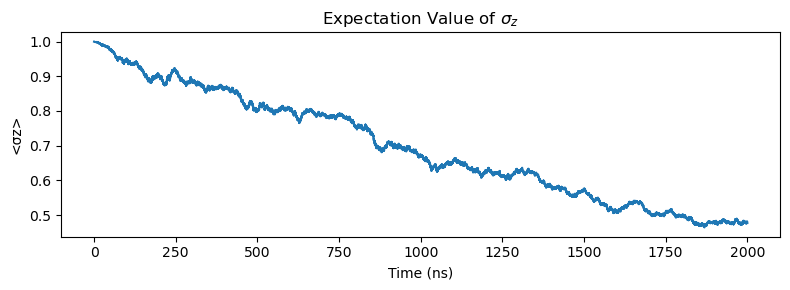

In [81]:
plot_tomography(t, [avgz], graphs="z")

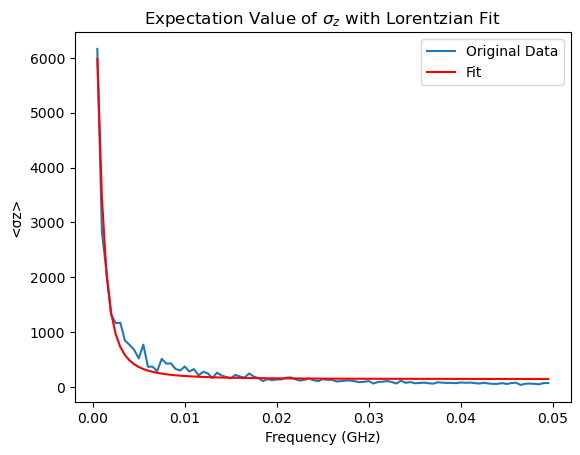

Fitted gamma: 8.52e-04
Fitted gamma*2pi: 5.35e-03
Fitted 1/gamma/2pi: 1.87e+02
Fitted Offset: 145.84
Fitted Amplitude : 7841.08
Fit
var of increments (volatility): 1.825549623092693e-07


In [82]:
lorenztian_fit(t, avgz, T2)

In [83]:
T1=10000 #relaxation time [ns]
T2=1000 #dephasing time [ns]
Ed=0.064*2*np.pi #driving energy [GHz.rad]
samples=5
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 5/5 [06:09<00:00, 73.86s/it]


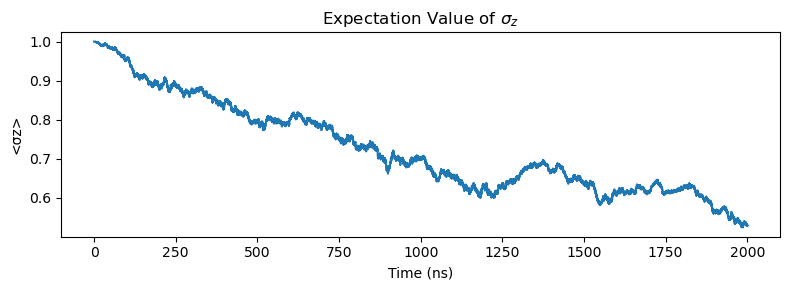

In [84]:
plot_tomography(t, [avgz], graphs="z")

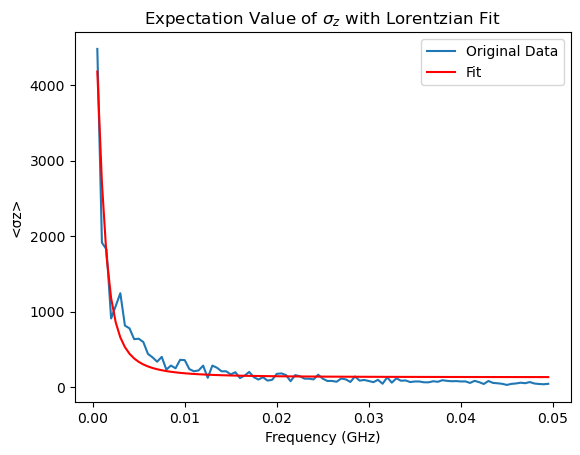

Fitted gamma: 1.03e-03
Fitted gamma*2pi: 6.47e-03
Fitted 1/gamma/2pi: 1.55e+02
Fitted Offset: 132.73
Fitted Amplitude : 4999.99
Fit
var of increments (volatility): 3.044083022972721e-07


In [85]:
lorenztian_fit(t, avgz, T2)

In [86]:
T1=10000 #relaxation time [ns]
T2=2000 #dephasing time [ns]
Ed=0.064*2*np.pi #driving energy [GHz.rad]
samples=5
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 5/5 [12:28<00:00, 149.68s/it]


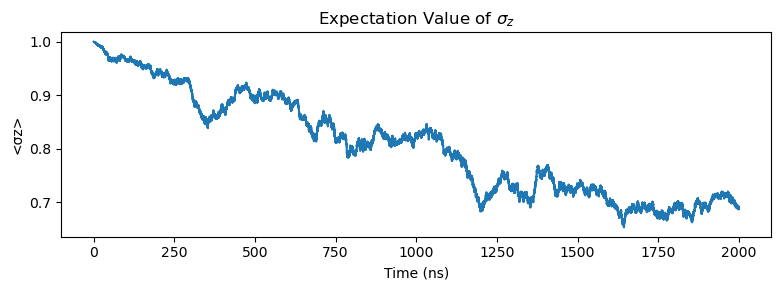

In [87]:
plot_tomography(t, [avgz], graphs="z")

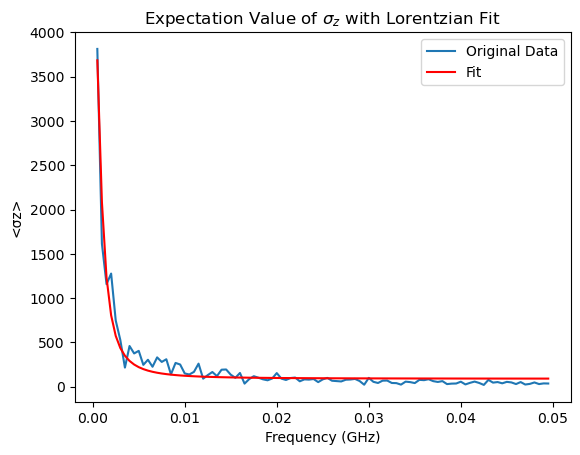

Fitted gamma: 8.26e-04
Fitted gamma*2pi: 5.19e-03
Fitted 1/gamma/2pi: 1.93e+02
Fitted Offset: 90.59
Fitted Amplitude : 4909.73
Fit
var of increments (volatility): 3.639325835166605e-07


In [88]:
lorenztian_fit(t, avgz, T2)

In [ ]:
T1=10000 #relaxation time [ns]
T2=4000 #dephasing time [ns]
Ed=0.064*2*np.pi #driving energy [GHz.rad]
samples=5
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

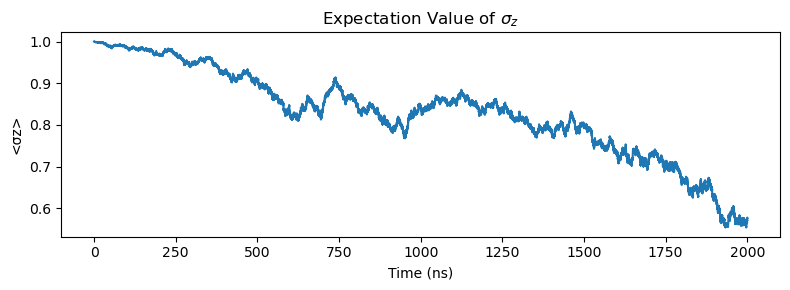

In [5]:
plot_tomography(t, [avgz], graphs="z")

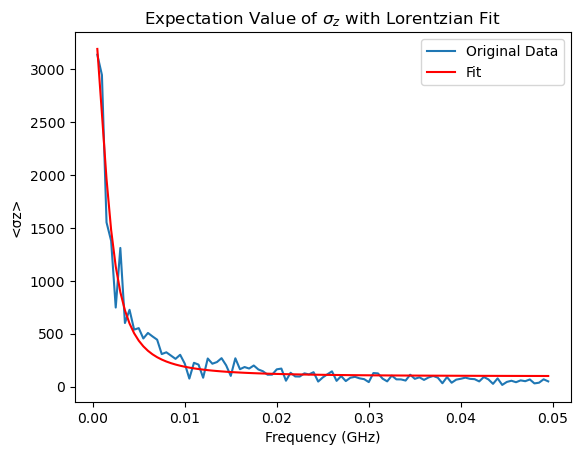

Fitted gamma: 1.67e-03
Fitted gamma*2pi: 1.05e-02
Fitted 1/gamma/2pi: 9.54e+01
Fitted Offset: 97.03
Fitted Amplitude : 3374.26
Fit
var of increments (volatility): 4.4079321821975544e-07


In [6]:
lorenztian_fit(t, avgz, T2)

In [8]:
T1=10000 #relaxation time [ns]
T2=10000 #dephasing time [ns]
Ed=0.064*2*np.pi #driving energy [GHz.rad]
samples=5
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 5/5 [06:40<00:00, 80.13s/it]


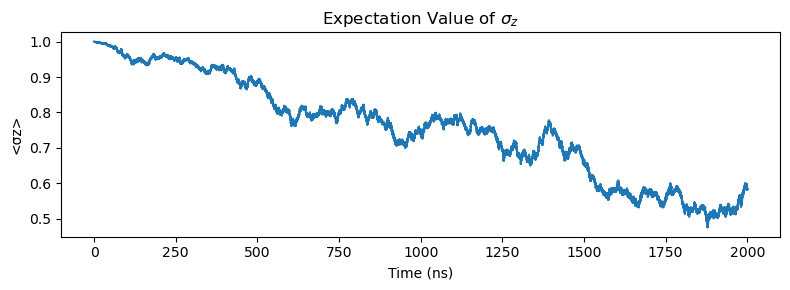

In [9]:
plot_tomography(t, [avgz], graphs="z")

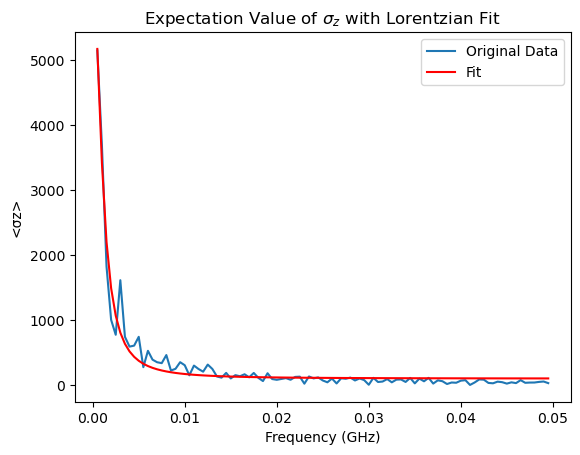

Fitted gamma: 1.08e-03
Fitted gamma*2pi: 6.79e-03
Fitted 1/gamma/2pi: 1.47e+02
Fitted Offset: 105.67
Fitted Amplitude : 6153.98
Fit
var of increments (volatility): 6.192513250138971e-07


In [10]:
lorenztian_fit(t, avgz, T2)

In [11]:
T1=10000 #relaxation time [ns]
T2=20000 #dephasing time [ns]
Ed=0.064*2*np.pi #driving energy [GHz.rad]
samples=5
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 5/5 [07:40<00:00, 92.11s/it] 


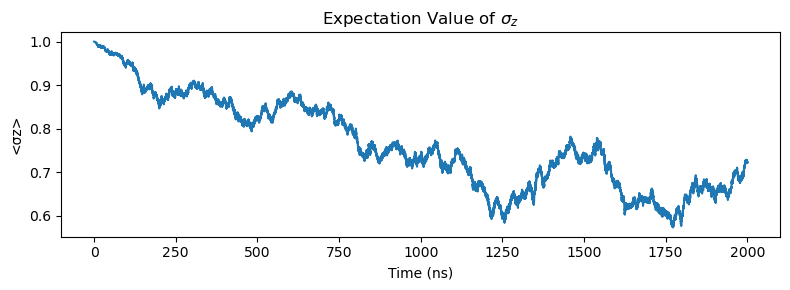

In [12]:
plot_tomography(t, [avgz], graphs="z")

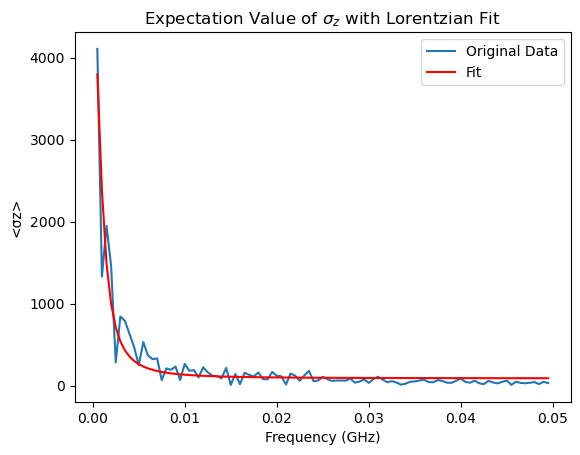

Fitted gamma: 9.82e-04
Fitted gamma*2pi: 6.17e-03
Fitted 1/gamma/2pi: 1.62e+02
Fitted Offset: 88.34
Fitted Amplitude : 4667.55
Fit
var of increments (volatility): 6.927470385628511e-07


In [13]:
lorenztian_fit(t, avgz, T2)

# End